Import Libraries

In [33]:
pip install dash plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 63.5 MB/s eta 0:00:00


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from dash import Dash, dcc, html, Input, Output

Load Dataset

In [5]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving OmairSalesDataProject (1).xlsx to OmairSalesDataProject (1).xlsx
User uploaded file "OmairSalesDataProject (1).xlsx" with length 107795 bytes


In [6]:
df = pd.read_excel('OmairSalesDataProject (1).xlsx')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1998 non-null   datetime64[ns]
 1   City    1998 non-null   object        
 2   Rep     1998 non-null   object        
 3   Store   1998 non-null   object        
 4   Prod    1998 non-null   object        
 5   Cost    1997 non-null   object        
 6   Sale    1998 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 109.4+ KB


Data Cleaning

Fix column names


In [7]:
df.columns = df.columns.str.strip().str.lower()

Convert data types


In [8]:
df['date'] = pd.to_datetime(df['date'])
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')
df['sale'] = pd.to_numeric(df['sale'], errors='coerce')

Fix inconsistent values

In [9]:
df['rep'] = df['rep'].replace({
    'Mjeeed': 'Mjeed'
})

df['store'] = df['store'].replace({
    'Lulu': 'Lulu Hyper'
})


Handle missing values


In [10]:
df = df.dropna(subset=['cost', 'sale'])
df['city'] = df['city'].fillna('Unknown')

Remove duplicates

In [11]:
df = df.drop_duplicates()

Feature Engineering

Add Profit


In [12]:
df['profit'] = df['sale'] - df['cost']

Add time features

In [13]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')

Exploratory Data Analysis (EDA)

asic overview

In [14]:
df.describe()

,date,cost,sale,profit,year,month
count,1996,1.996000e+03,1996.000000,1.996000e+03,1996.000000,1996.000000
mean,2005-06-23 10:03:50.861723520,2.819872e+04,5043.958873,-2.315476e+04,2004.979960,6.484970
min,2004-06-17 00:00:00,7.410400e+00,12.560000,-4.999212e+07,2004.000000,1.000000
25%,2004-12-21 00:00:00,1.458104e+03,2574.467500,5.577291e+02,2004.000000,3.000000
50%,2005-06-20 00:00:00,2.963455e+03,4977.625000,1.510727e+03,2005.000000,7.000000
75%,2005-12-22 00:00:00,4.456884e+03,7527.485000,2.934070e+03,2005.000000,9.000000
max,2015-12-28 00:00:00,5.000000e+07,9994.240000,6.292793e+03,2015.000000,12.000000
std,NaN,1.119085e+06,2874.584425,1.119021e+06,0.792572,3.472524


Total metrics

In [15]:
total_sales = df['sale'].sum()
total_profit = df['profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 10067741.91
Total Profit: -46216893.31395


Grouped analysis

Sales by City

In [16]:
sales_by_city = df.groupby('city')['sale'].sum().sort_values(ascending=False)
print(sales_by_city)

city
Dammam    1873614.87
Riyadh    1797653.68
Jeddah    1708037.57
Abha      1644938.73
Jubail    1562105.63
Hail      1481391.43
Name: sale, dtype: float64


Sales by Product

In [18]:
sales_by_product = df.groupby('prod')['sale'].sum().sort_values(ascending=False)
print(sales_by_product)

prod
Food      2684659.16
Office    2623694.23
Toys      2445342.41
Home      2314046.11
Name: sale, dtype: float64


Sales by Rep

In [19]:
sales_by_rep = df.groupby('rep')['sale'].sum().sort_values(ascending=False)
print(sales_by_rep)

rep
Yahia     2177923.20
Ghalia    2107132.67
Maliha    2088024.54
Mjeed     1877766.01
Abdul     1816895.49
Name: sale, dtype: float64


Statistical Analysis

Key statistics

In [20]:
print("Mean Sales:", df['sale'].mean())
print("Min Sales:", df['sale'].min())
print("Max Sales:", df['sale'].max())
print("Std Dev:", df['sale'].std())

Mean Sales: 5043.958872745491
Min Sales: 12.56
Max Sales: 9994.24
Std Dev: 2874.5844252813745


Profit distribution

In [21]:
df['profit'].describe()

,profit
count,1.996000e+03
mean,-2.315476e+04
std,1.119021e+06
min,-4.999212e+07
25%,5.577291e+02
50%,1.510727e+03
75%,2.934070e+03
max,6.292793e+03


# Visualizations

Sales Trend (Line Chart)

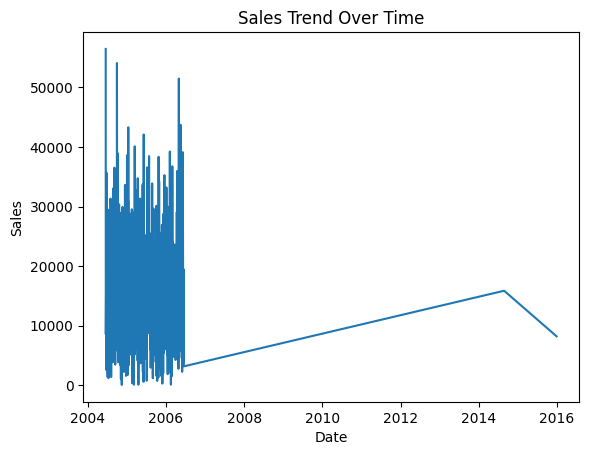

In [22]:
sales_trend = df.groupby('date')['sale'].sum()

plt.figure()
plt.plot(sales_trend)
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

Sales by City (Bar Chart)

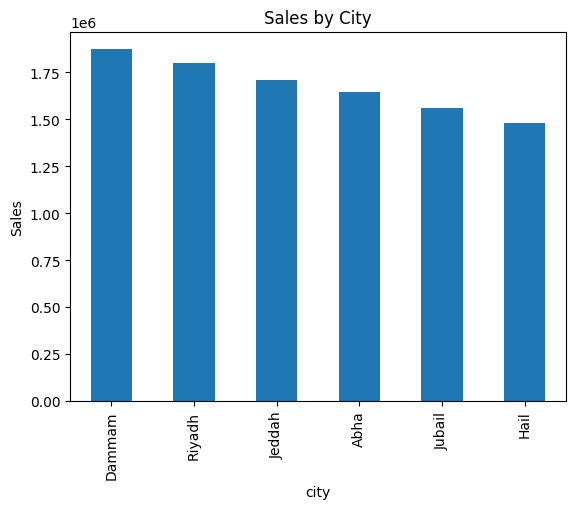

In [23]:
sales_by_city.plot(kind='bar')
plt.title("Sales by City")
plt.ylabel("Sales")
plt.show()

Product Contribution (Pie Chart)

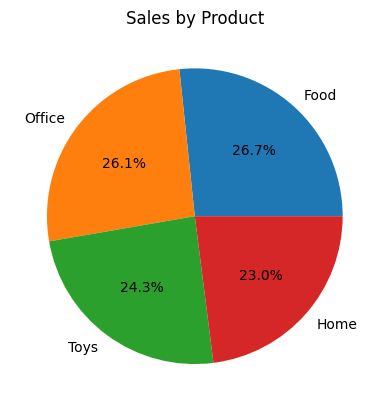

In [24]:
sales_by_product.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Product")
plt.ylabel("")
plt.show()

Rep Performance

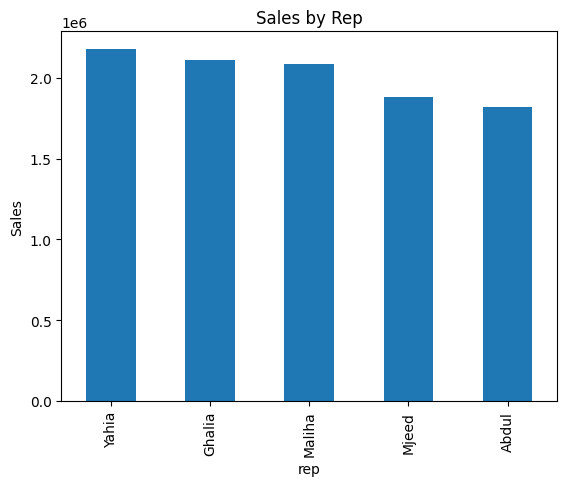

In [25]:
sales_by_rep.plot(kind='bar')
plt.title("Sales by Rep")
plt.ylabel("Sales")
plt.show()

Profit Distribution

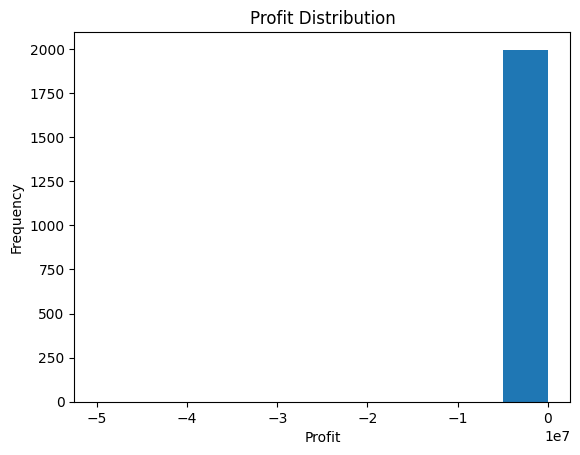

In [26]:
plt.figure()
plt.hist(df['profit'])
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

# Insights

Total sales show steady growth over time.
Certain cities contribute most of the revenue.
A few reps dominate sales performance.
 Profit variability indicates potential pricing or cost issues.

In [31]:
total_sales = df['sale'].sum()
total_profit = df['profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 10067741.91
Total Profit: -46216893.31395


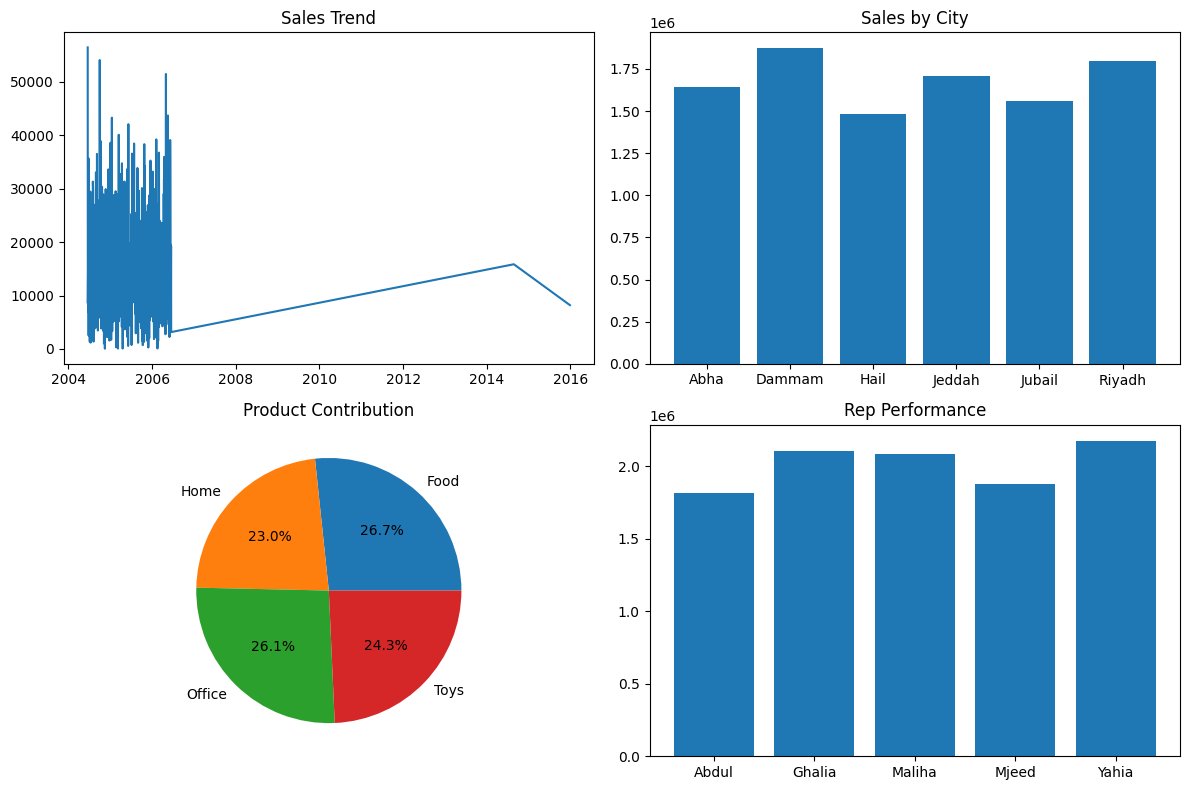

In [32]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1) Sales Trend
sales_trend = df.groupby('date')['sale'].sum()
axes[0, 0].plot(sales_trend)
axes[0, 0].set_title("Sales Trend")

# 2) Sales by City
sales_by_city = df.groupby('city')['sale'].sum()
axes[0, 1].bar(sales_by_city.index, sales_by_city.values)
axes[0, 1].set_title("Sales by City")

# 3) Sales by Product
sales_by_product = df.groupby('prod')['sale'].sum()
axes[1, 0].pie(sales_by_product, labels=sales_by_product.index, autopct='%1.1f%%')
axes[1, 0].set_title("Product Contribution")

# 4) Sales by Rep
sales_by_rep = df.groupby('rep')['sale'].sum()
axes[1, 1].bar(sales_by_rep.index, sales_by_rep.values)
axes[1, 1].set_title("Rep Performance")

plt.tight_layout()
plt.show()